In [6]:
import os
import numpy as np
import rasterio as rio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

os.chdir(r"/Users/hrchapmandutton/Documents/Projects/CDW")

In [7]:
net_path = r'RF_net_2001_2019_raster.tif'

albedo_path = r'RF_albedo_2001_2019_raster.tif'
ghg_path = r'RF_greenhousgasses_2001_2019_raster.tif'
perma_path = r'RF_permafrost_2001_2019_raster.tif'
recovery_path = r'RF_recovery_2001_2019_raster.tif'

eco_path = r'Ecoregions_lvl1.tif'
boundaries_path = r'Political_Boundaries_AK_CA.tif'

In [8]:
paths = [net_path, albedo_path, ghg_path, perma_path, recovery_path, eco_path, boundaries_path]

In [9]:
#open raster functions
def open_raster(rast_path): 
    with rio.open(rast_path) as src:
        rast = src.read(1)
        nodata = src.nodatavals[0]
        if nodata is not None:
            rast = np.where(rast == nodata, np.nan, rast)
    vals = rast.flatten()
    clean_vals = vals[~np.isnan(vals)]
    return clean_vals

In [10]:
summary_path = 'raster_summary_stats.csv'

plot_rasters = ['net', 'albedo', 'ghg', 'perma', 'recovery']
boundary_rasters = ['eco', 'boundaries']

path_lookup = {
    name.removesuffix('_path'): value
    for name, value in globals().items()
    if name.endswith('_path') and value in paths
}

stats_rows = []
for label in plot_rasters:
    path = path_lookup[label]
    vals = open_raster(path)
    stats_rows.append({
        'raster': label,
        'n': vals.size,
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals)),
        'q1': float(np.percentile(vals, 25)),
        'median': float(np.percentile(vals, 50)),
        'q3': float(np.percentile(vals, 75)),
        'min': float(np.min(vals)),
        'max': float(np.max(vals))
    })

stats_df = pd.DataFrame(stats_rows).sort_values('raster').reset_index(drop=True)
#stats_df.to_csv(summary_path, index=False)
stats_df

,raster,n,mean,std,q1,median,q3,min,max
0,albedo,11367806,-8.143490,4.993004,-8.831398,-7.057048,-5.842733,-1.590960e+02,-3.084125
1,ghg,11367806,8.981025,2.312942,8.185896,9.018252,9.859766,8.298400e-07,105.260811
2,net,11367806,-0.806054,5.394626,-2.464749,-0.791149,1.290770,-1.084106e+02,60.835339
3,perma,11367806,1.872831,2.750422,0.000000,0.958083,2.530979,0.000000e+00,31.234245
4,recovery,11367806,-0.579369,0.204467,-0.706629,-0.584144,-0.435244,-1.239307e+00,0.131502


In [11]:
reg_rows = []
for region in plot_rasters:
    path = path_lookup[region]
    vals = open_raster(path)
    reg_rows.append({
        'region': region,
        'n': vals.size,
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals)),
        'q1': float(np.percentile(vals, 25)),
        'median': float(np.percentile(vals, 50)),
        'q3': float(np.percentile(vals, 75)),
        'min': float(np.min(vals)),
        'max': float(np.max(vals))
    })

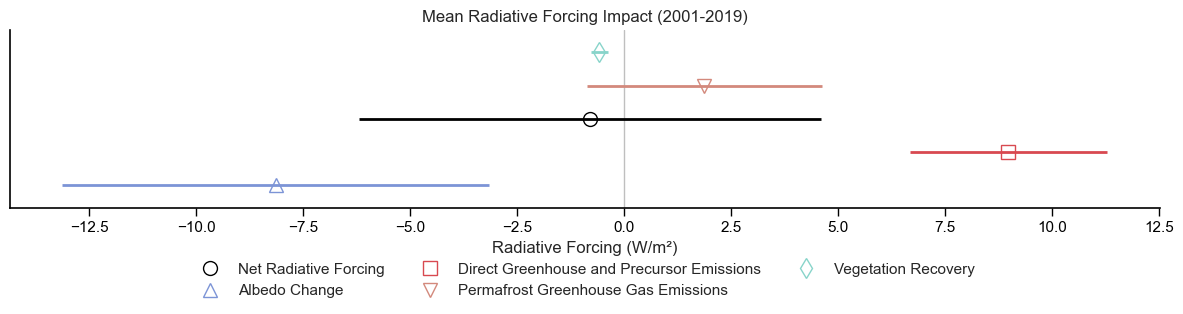

In [24]:
# Reuse this on later runs to avoid re-reading all rasters:
# stats_df = pd.read_csv(summary_path)

plot_df = stats_df.sort_values('raster').reset_index(drop=True)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 3))

style_map = {
    'net': {'color': '#000000', 'marker': 'o', 'label': 'Net Radiative Forcing'},
    'albedo': {'color': '#7c94d6', 'marker': '^', 'label': 'Albedo Change'},
    'ghg': {'color': '#d84950', 'marker': 's', 'label': 'Direct Greenhouse and Precursor Emissions'},
    'perma': {'color': '#d3897c', 'marker': 'v', 'label': 'Permafrost Greenhouse Gas Emissions'},
    'recovery': {'color': '#88d4ca', 'marker': 'd', 'label': 'Vegetation Recovery'}
}

# Smaller step = tighter rows. Keep pad fixed so spacing change is visible.
y_step = 0.03
y_pad = 0.02

for i, row in plot_df.iterrows():
    style = style_map.get(
        row['raster'],
        {'color': '#666666', 'marker': 'o', 'label': row['raster']}
    )
    y_pos = i * y_step
    ax.errorbar(
        row['mean'],
        y_pos,
        xerr=row['std'],
        fmt=style['marker'],
        markersize=10,
        markerfacecolor='none',
        markeredgecolor=style['color'],
        color=style['color'],
        ecolor=style['color'],
        elinewidth=2,
        capsize=0,
        linestyle='none'
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker=style['marker'],
        color='none',
        markeredgecolor=style['color'],
        markerfacecolor='none',
        markersize=10,
        linestyle='none',
        label=style['label']
    )
    for style in style_map.values()
 ]
ax.legend(
    handles=legend_handles,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.23),
    ncol=3
)

ax.set_yticks([])
ax.set_ylabel('')
ax.set_ylim(-y_pad, (len(plot_df) - 1) * y_step + y_pad)
ax.set_title('Mean Radiative Forcing Impact (2001-2019)')
ax.set_xlabel('Radiative Forcing (W/m²)')
ax.grid(False)
ax.axvline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

ax.xaxis.set_major_locator(MultipleLocator(2.5))
ax.tick_params(
    axis='x',
    which='major',
    direction='out',
    bottom=True,
    top=False,
    length=6,
    width=1.0,
    colors='black'
 )

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()

In [28]:
ecoRF = pd.read_excel(r'ecoregion_netRF_basic.xlsx', sheet_name='Sheet1')
ecoRF

,Region,Ecoregion,net RF,Ecoregion Percent
0,British Columbia,NORTH AMERICAN DESERTS,3.331470,5.643621
1,Alaska,TUNDRA,6.322681,33.766593
2,Manitoba,TUNDRA,-1.621587,0.216680
3,Northwest Territories,TUNDRA,0.109833,29.165902
4,Yukon,TUNDRA,4.662858,5.715532
5,Alaska,TAIGA,6.322681,27.324290
6,Alberta,TAIGA,0.581837,15.686865
7,British Columbia,TAIGA,3.331470,7.120767
8,Manitoba,TAIGA,-1.621587,20.243298
9,Northwest Territories,TAIGA,0.109833,70.317534


In [29]:
ecos = ecoRF['Ecoregion'].value_counts()
eco_multi = ecos[ecos > 1].index.tolist()
eco_multi

['TAIGA',
 'NORTHWESTERN FORESTED MOUNTAINS',
 'TUNDRA',
 'NORTHERN FORESTS',
 'MARINE WEST COAST FOREST',
 'GREAT PLAINS']

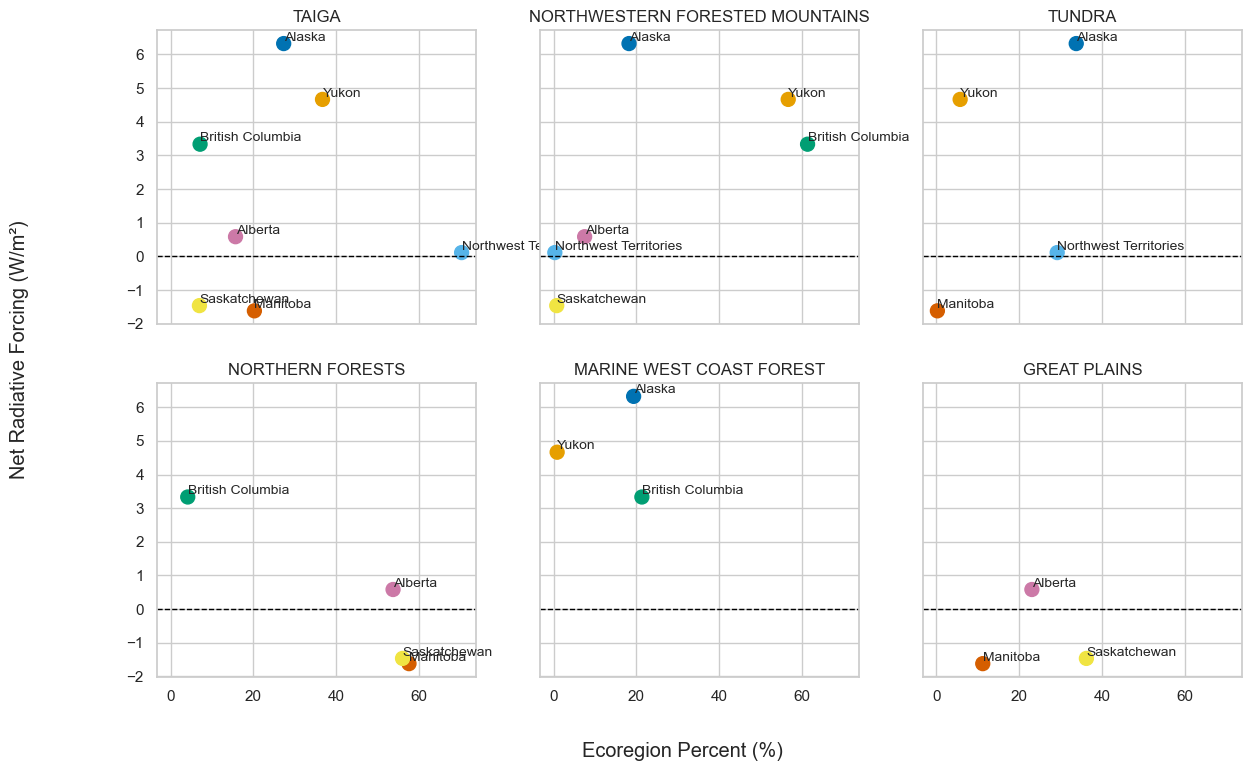

In [43]:
colormap = {
    'Alaska': '#0072B2',
    'Yukon': '#E69F00',
    'Northwest Territories': '#56B4E9',
    'British Columbia': '#009E73',
    'Alberta': '#CC79A7',
    'Saskatchewan': '#F0E442',
    'Manitoba': '#D55E00'
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 2.8 * 3),
    sharex=True,
    sharey=True
)

for ax, eco in zip(axes.flatten(), eco_multi):
    sub = ecoRF[ecoRF['Ecoregion'] == eco]
    sub_colors = sub['Region'].map(colormap).fillna('#999999')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.scatter(
        data=sub,
        x='Ecoregion Percent',
        y='net RF',
        c=sub_colors,
        s=100
    )
    for _, row in sub.iterrows():
        ax.text(
            row['Ecoregion Percent'],
            row['net RF'],
            row['Region'],
            fontsize=10,
            ha='left',
            va='bottom'
        )
    ax.set_title(eco)
    fig.supxlabel('Ecoregion Percent (%)')
    fig.supylabel('Net Radiative Forcing (W/m²)')
plt.show()